<a href="https://colab.research.google.com/github/mr-zero-000/Statistical-Learning-e23034/blob/main/Assignment%205/Part%2004/Part_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install factor_analyzer -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 2.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


UPLOAD YOUR SENSOR CSV FILE


Saving sensor_data.csv to sensor_data.csv

Loaded: sensor_data.csv
   Sensor_1  Sensor_2  Sensor_3  Sensor_4
0      10.2      10.1       9.8      10.0
1      10.5      10.3       9.9      10.2
2      10.7      10.6      10.1      10.4
3      11.0      10.9      10.4      10.6
4      11.2      11.1      10.6      10.8


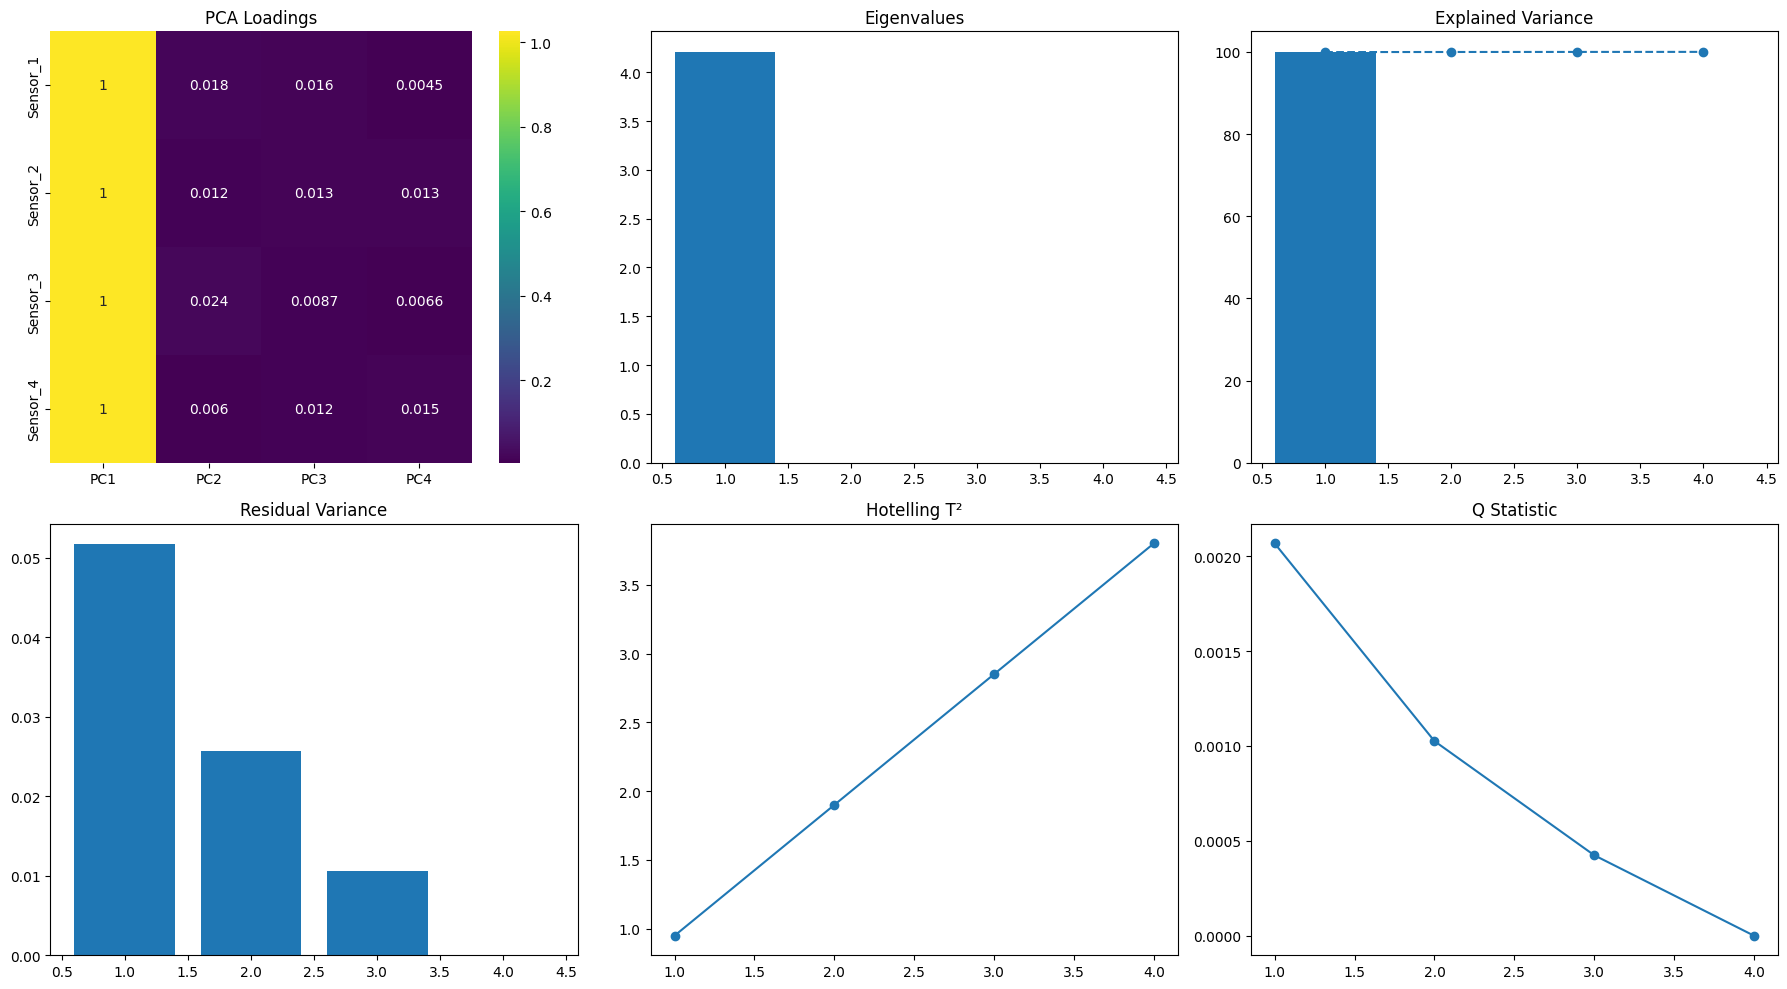

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


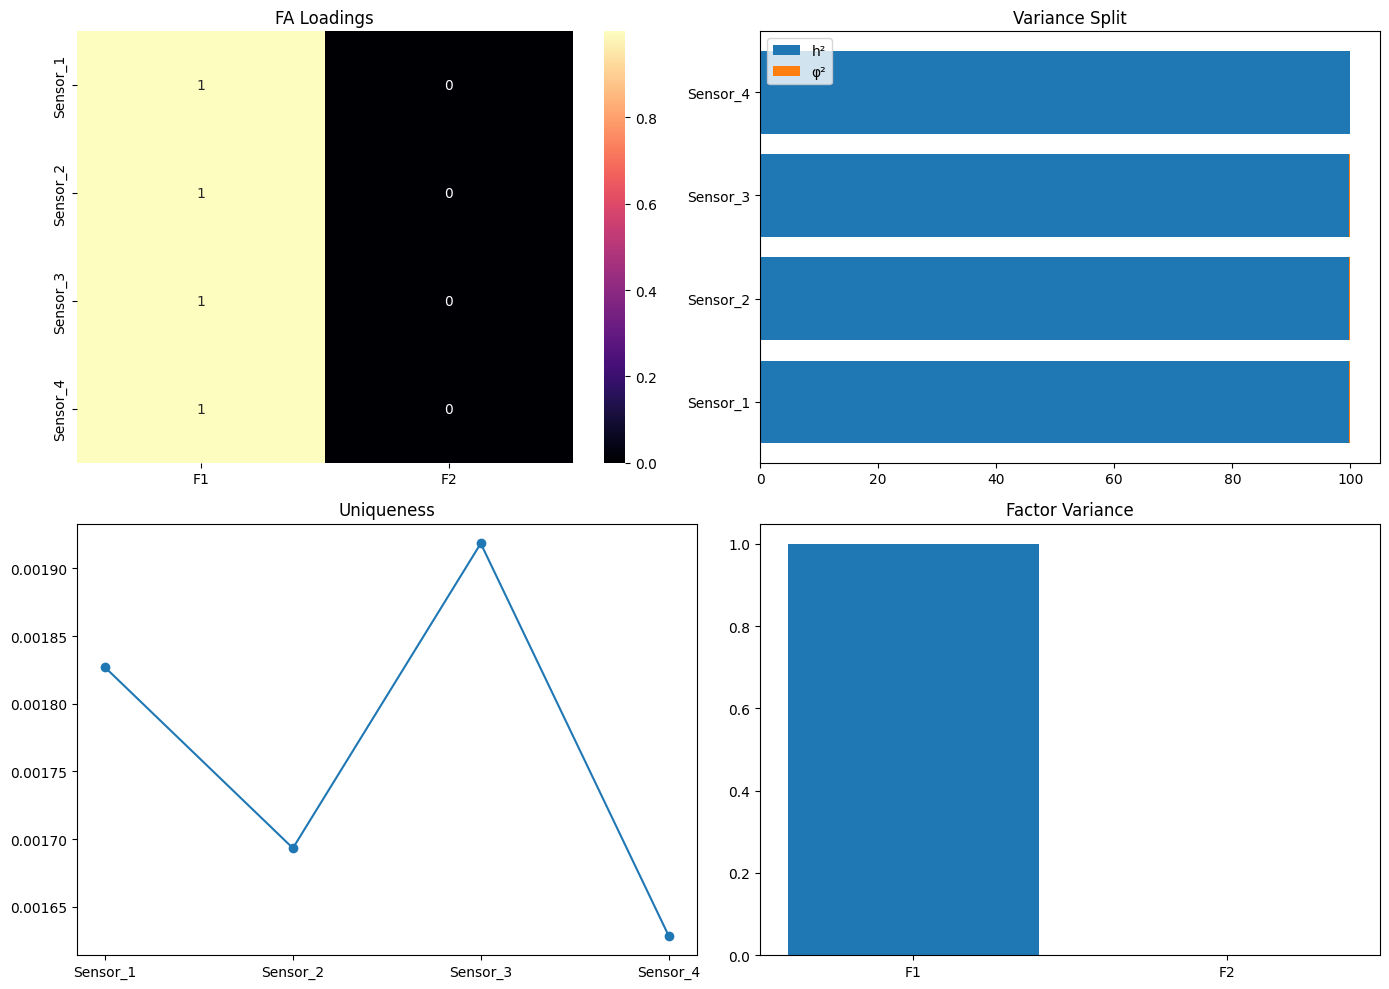


Excel file created: SHM_results.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
# ==========================================================
# COMPLETE SHM PCA + FA PIPELINE (ONE CELL)
# ==========================================================

!pip install factor_analyzer openpyxl -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from factor_analyzer import FactorAnalyzer


# ==========================================================
# 1. UPLOAD FILE
# ==========================================================

print("UPLOAD YOUR SENSOR CSV FILE")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("\nLoaded:", filename)
print(df.head())


# ==========================================================
# 2. VALIDATION
# ==========================================================

cols = ['Sensor_1','Sensor_2','Sensor_3','Sensor_4']

missing = [c for c in cols if c not in df.columns]

if missing:
    raise ValueError(f"Missing columns: {missing}")

X = df[cols].values

# ==========================================================
# 3. STANDARDIZE
# ==========================================================

scaler = StandardScaler()
Xs = scaler.fit_transform(X)

n, m = Xs.shape


# ==========================================================
# 4. PCA
# ==========================================================

pca = PCA(n_components=m)
scores = pca.fit_transform(Xs)

eigenvalues = pca.explained_variance_
explained = pca.explained_variance_ratio_ * 100
cumulative = np.cumsum(explained)

loadings = pca.components_.T * np.sqrt(eigenvalues)


# T2 + Q
t2_list, q_list = [], []

for k in range(1, m+1):

    Tk = scores[:, :k]
    lk = eigenvalues[:k]

    T2 = np.sum((Tk**2)/lk, axis=1)
    t2_list.append(np.mean(T2))

    Pk = pca.components_[:k, :]
    Xhat = Tk @ Pk
    Q = np.sum((Xs - Xhat)**2, axis=1)
    q_list.append(np.mean(Q))


# ==========================================================
# 5. PCA DASHBOARD
# ==========================================================

fig, ax = plt.subplots(2,3, figsize=(18,10))

sns.heatmap(np.abs(loadings),
            annot=True,
            cmap='viridis',
            xticklabels=[f'PC{i+1}' for i in range(m)],
            yticklabels=cols,
            ax=ax[0,0])

ax[0,0].set_title("PCA Loadings")

ax[0,1].bar(range(1,m+1), eigenvalues)
ax[0,1].set_title("Eigenvalues")

ax[0,2].bar(range(1,m+1), explained)
ax[0,2].plot(range(1,m+1), cumulative, 'o--')
ax[0,2].set_title("Explained Variance")

ax[1,0].bar(range(1,m+1), 100-cumulative)
ax[1,0].set_title("Residual Variance")

ax[1,1].plot(range(1,m+1), t2_list, marker='o')
ax[1,1].set_title("Hotelling T²")

ax[1,2].plot(range(1,m+1), q_list, marker='o')
ax[1,2].set_title("Q Statistic")

plt.tight_layout()
plt.show()


# ==========================================================
# 6. FACTOR ANALYSIS
# ==========================================================

fa = FactorAnalyzer(n_factors=2, rotation='varimax')
fa.fit(Xs)

fa_load = fa.loadings_
h2 = fa.get_communalities()
u2 = fa.get_uniquenesses()

fs = fa.transform(Xs)
fs_var = np.var(fs, axis=0)


# ==========================================================
# 7. FA DASHBOARD
# ==========================================================

fig, ax = plt.subplots(2,2, figsize=(14,10))

sns.heatmap(np.abs(fa_load),
            annot=True,
            cmap='magma',
            xticklabels=['F1','F2'],
            yticklabels=cols,
            ax=ax[0,0])

ax[0,0].set_title("FA Loadings")

ax[0,1].barh(cols, h2*100, label='h²')
ax[0,1].barh(cols, u2*100, left=h2*100, label='φ²')
ax[0,1].legend()
ax[0,1].set_title("Variance Split")

ax[1,0].plot(cols, u2, marker='o')
ax[1,0].set_title("Uniqueness")

ax[1,1].bar(['F1','F2'], fs_var)
ax[1,1].set_title("Factor Variance")

plt.tight_layout()
plt.show()


# ==========================================================
# 8. EXPORT RESULTS
# ==========================================================

out = pd.ExcelWriter("SHM_results.xlsx")

pd.DataFrame({
    "Eigenvalues": eigenvalues,
    "Explained%": explained,
    "Cumulative%": cumulative
}).to_excel(out, sheet_name="PCA", index=False)

pd.DataFrame({
    "Sensor": cols,
    "Communality": h2,
    "Uniqueness": u2
}).to_excel(out, sheet_name="FA", index=False)

out.close()

print("\nExcel file created: SHM_results.xlsx")

files.download("SHM_results.xlsx")